# PixelMind — Week 7: Transfer Learning Web App (Flower Classificaition)

Phase 2: Deep Learning Foundations — Part 2 of ?

Last week, I built a CNN from scratch and trained it on MNIST.

This week, the goal shifts from building models from zero to leveraging powerful pretrained networks.

The question:

> Instead of training from scratch, can we use knowledge from massive datasets to solve a new problem faster and better?

In this project, I fine-tune a pretrained CNN (ResNet) using PyTorch to classify flower species from the Flowers102 dataset, then deploy the model as an interactive web application.

# Objectives
Build a flower classification system that:
- Uses a pretrained ResNet model
- Applies transfer learning
- Achieves strong accuracy on flower categories
- Is deployed via a simple web interface using Streamlit
Users can:
1. Upload a flower image
2. Click predict
3. Instantly see the predicted flower class

In [23]:
# Import packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Device Setup

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


# Step 2: Loading the flowers102 Dataset

- A dataset of 102 flower species

- Designed for flower category classification

- Each class has 40–258 images of flowers in the wild

In [25]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.Flowers102(
    root="./data",
    split='train',
    download=True,
    transform=train_transform
)

test_dataset = datasets.Flowers102(
    root='./data',
    split='val',
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 1020
Test samples: 1020


# Step 3: Visualizing Training Samples

In [26]:
print(train_dataset.classes[:10])

['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle']


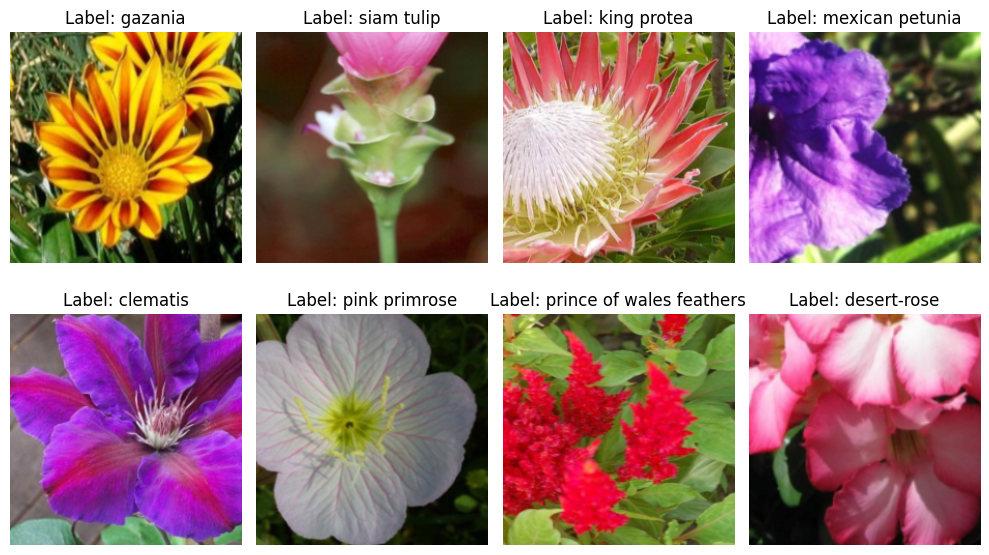

In [27]:
# Helper function to denormalize and display image
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    # Denormalize
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

examples = iter(train_loader)
images, labels = next(examples)

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(f"Label: {train_dataset.classes[labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Step 4: Load the pretrained ResNet50

In [28]:
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in resnet_model.parameters():
  param.requires_grad = False

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 102)

resnet_model = resnet_model.to(device)


print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Step 5: Loss Function and Optimizer

In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.fc.parameters(), lr=.001)

# Step 6: Training the Model

In [35]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, device):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
        # TRAINING
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
    
        for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
    
          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
    
          running_loss += loss.item()
    
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
    
        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)
    
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
    
        # VALIDATION
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
    
        with torch.no_grad():
          for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
    
            outputs = model(images)
            loss = criterion(outputs, labels)
    
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        val_loss /= len(val_loader)
    
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
    
        print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
                  f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
    return train_losses, val_losses, train_accuracies, val_accuracies

# Phase 1

In [36]:
train_losses_1, val_losses_1, train_accs_1, val_accs_1 = train_model(
    resnet_model,
    train_loader,
    test_loader,
    optimizer,
    criterion,
    epochs=30,
    device=device
)

Epoch [1/30] Train Loss: 0.3216 | Train Acc: 96.27% | Val Loss: 0.6923 | Val Acc: 86.57%
Epoch [2/30] Train Loss: 0.3025 | Train Acc: 96.37% | Val Loss: 0.6710 | Val Acc: 87.06%
Epoch [3/30] Train Loss: 0.2825 | Train Acc: 96.37% | Val Loss: 0.6676 | Val Acc: 86.47%
Epoch [4/30] Train Loss: 0.3009 | Train Acc: 96.08% | Val Loss: 0.6544 | Val Acc: 85.88%
Epoch [5/30] Train Loss: 0.2595 | Train Acc: 97.94% | Val Loss: 0.6738 | Val Acc: 86.18%
Epoch [6/30] Train Loss: 0.2469 | Train Acc: 97.25% | Val Loss: 0.6459 | Val Acc: 87.45%
Epoch [7/30] Train Loss: 0.2490 | Train Acc: 96.76% | Val Loss: 0.6366 | Val Acc: 86.96%
Epoch [8/30] Train Loss: 0.2447 | Train Acc: 96.76% | Val Loss: 0.6176 | Val Acc: 87.16%
Epoch [9/30] Train Loss: 0.2320 | Train Acc: 97.45% | Val Loss: 0.6355 | Val Acc: 86.67%
Epoch [10/30] Train Loss: 0.2407 | Train Acc: 96.86% | Val Loss: 0.6083 | Val Acc: 87.45%
Epoch [11/30] Train Loss: 0.2213 | Train Acc: 97.45% | Val Loss: 0.6107 | Val Acc: 87.06%
Epoch [12/30] Train

# Phase 2

In [37]:
for param in resnet_model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-5)

train_losses_2, val_losses_2, train_accs_2, val_accs_2 = train_model(
    resnet_model,
    train_loader,
    test_loader,
    optimizer,
    criterion,
    epochs=15,
    device=device
)

Epoch [1/15] Train Loss: 0.1322 | Train Acc: 98.04% | Val Loss: 0.4977 | Val Acc: 87.75%
Epoch [2/15] Train Loss: 0.1043 | Train Acc: 98.24% | Val Loss: 0.4675 | Val Acc: 88.53%
Epoch [3/15] Train Loss: 0.1063 | Train Acc: 97.65% | Val Loss: 0.4647 | Val Acc: 88.24%
Epoch [4/15] Train Loss: 0.1018 | Train Acc: 98.14% | Val Loss: 0.4552 | Val Acc: 88.63%
Epoch [5/15] Train Loss: 0.1073 | Train Acc: 97.75% | Val Loss: 0.4620 | Val Acc: 87.65%
Epoch [6/15] Train Loss: 0.0881 | Train Acc: 97.65% | Val Loss: 0.4584 | Val Acc: 88.33%
Epoch [7/15] Train Loss: 0.0768 | Train Acc: 97.94% | Val Loss: 0.4331 | Val Acc: 88.63%
Epoch [8/15] Train Loss: 0.0732 | Train Acc: 98.53% | Val Loss: 0.4381 | Val Acc: 88.82%
Epoch [9/15] Train Loss: 0.0974 | Train Acc: 97.65% | Val Loss: 0.4414 | Val Acc: 88.82%
Epoch [10/15] Train Loss: 0.0542 | Train Acc: 99.12% | Val Loss: 0.4283 | Val Acc: 88.92%
Epoch [11/15] Train Loss: 0.0768 | Train Acc: 98.33% | Val Loss: 0.4397 | Val Acc: 88.33%
Epoch [12/15] Train

In [38]:
train_losses = train_losses_1 + train_losses_2
val_losses = val_losses_1 + val_losses_2
train_accs = train_accs_1 + train_accs_2
val_accs = val_accs_1 + val_accs_2

## Step 7: Visualizing Training Loss

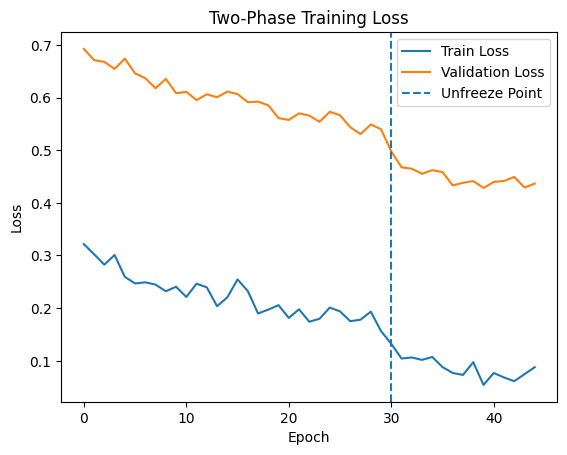

In [39]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.axvline(x=30, linestyle='--', label="Unfreeze Point")
plt.legend()
plt.title("Two-Phase Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [40]:
torch.save(resnet_model.state_dict(), "resnet50_flowers102.pth")

In [41]:
torch.save(resnet_model, "resnet50_full_model.pth")

In [43]:
def visualize_predictions(model, loader, device, class_names, num_images=6):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(12, 6))

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].cpu()

                # Unnormalize (important!)
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
                img = img * std + mean
                img = torch.clamp(img, 0, 1)

                plt.subplot(2, 3, images_shown + 1)
                plt.imshow(img.permute(1, 2, 0))
                plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}")
                plt.axis("off")

                images_shown += 1

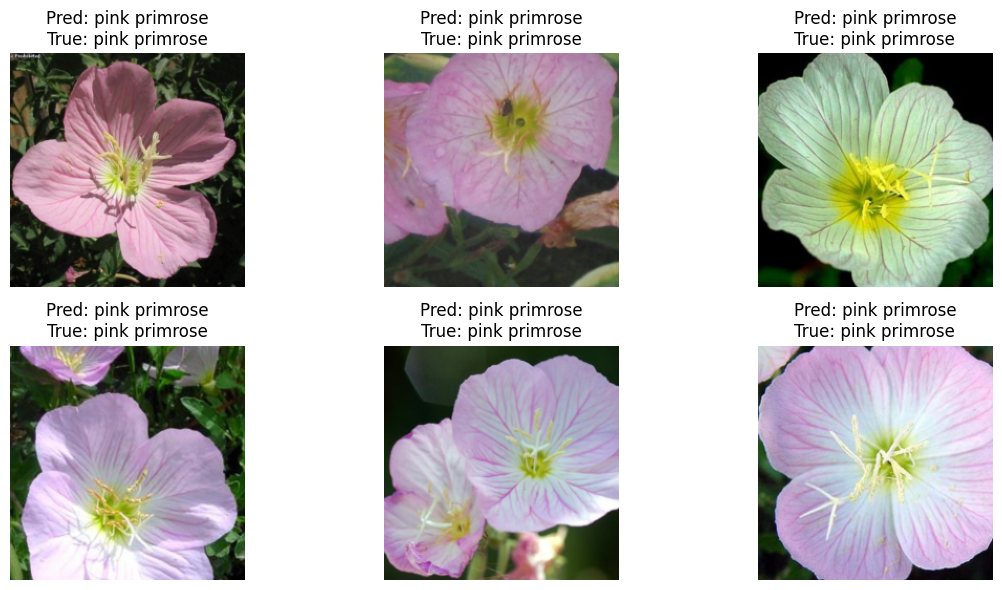

In [46]:
class_names = train_dataset.classes

visualize_predictions(
    resnet_model,
    test_loader,
    device,
    class_names,
    num_images=6
)